# Final Training for Attention-Based Bi-LSTM with Data Augmentation and Feature Engineering

This notebook performs final model training on the complete training set after cross-validation optimization. The trained model is evaluated on the held-out test set at multiple granularities (sequence, file, and person levels) with comprehensive attention weight analysis to understand the model's decision-making process.

# Configuration and Setup

Setting up the environment for reproducible final model training:
- **Seed Configuration**: Fixed random seed (42) across all libraries (Python, NumPy, TensorFlow)
- **Deterministic Operations**: TensorFlow configured for deterministic GPU operations
- **Channel Selection**: Five key handwriting dynamics features (Fingergrip, Axial Pressure, Tilt X/Y/Z)
- **Environment Variables**: PYTHONHASHSEED and TF_DETERMINISTIC_OPS set for consistency

In [22]:
# =====================================
# CONFIGURATION AND SETUP
# =====================================

import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import scipy.interpolate as interp
from sklearn.utils import class_weight
import pickle
from scipy.stats import entropy

# SET SEEDS FOR REPRODUCIBILITY
seed = 42

# Must be set before importing TensorFlow
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import tensorflow as tf

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Set pandas display options
pd.set_option('display.max_columns', None)

# Updated channel names (excluding Microphone)
channel_names = [
    "Fingergrip", "Axial_Pressure",
    "Tilt_X", "Tilt_Y", "Tilt_Z"
]

# Data Loading

Loading preprocessed training and testing datasets with applied augmentation and feature engineering:
- **Training Data**: Complete augmented training set for final model training
- **Testing Data**: Held-out test set never seen during training or cross-validation
- **Data Format**: Pickle files containing windowed sequences with labels and metadata
- **Features Included**: Statistical features, mass calculations, delta values, and temporal patterns

In [23]:
# =====================================
# LOAD THE CLEAN, SPLIT DATA
# =====================================

df_train = pd.read_pickle('C:/Users/steph/Downloads/df_train.pkl')
df_test = pd.read_pickle('C:/Users/steph/Downloads/df_test.pkl')

print("Clean data loaded.")
print(f"Training samples: {len(df_train)}")
print(f"Testing samples: {len(df_test)}")

Clean data loaded.
Training samples: 32637
Testing samples: 2577


# Model Dependencies

Importing essential libraries for deep learning model construction and evaluation:
- **TensorFlow/Keras**: Neural network architecture (Bi-LSTM, Attention layers)
- **Optimization**: Adam optimizer with learning rate scheduling and regularization
- **Metrics**: Classification reports, confusion matrices, ROC/PR curves, AUC scores
- **Data Splitting**: Train-test split utilities for final evaluation

In [24]:
# =====================================
# IMPORTS FOR MODELING
# =====================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_curve, average_precision_score, roc_curve, auc
import seaborn as sns
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.losses import BinaryCrossentropy
from sklearn.model_selection import train_test_split


# Sequence Generation and Normalization

Creating overlapping temporal sequences from windowed data for LSTM processing:
- **Sequence Length**: 20 consecutive windows per sequence
- **Step Size**: 10 windows overlap to capture temporal continuity
- **Feature Selection**: Excluding metadata columns (label, file_name, Person_ID, demographics)
- **Standardization**: StandardScaler fitted on training data and applied to both train and test sets
- **Output Shape**: (n_sequences, 20, n_features) for Bi-LSTM input

In [25]:
# =====================================
# CREATE SEQUENCES OF WINDOWS
# =====================================

def create_sequences(df, feature_cols, sequence_length, step_size):
    sequences = []
    labels = []
    file_names = []
    person_ids = []
    grouped = df.groupby('file_name')
    print(f"Creating sequences of length {sequence_length} with step {step_size}...")
    for file_name, group in tqdm(grouped):
        features = group[feature_cols].values
        if len(features) < sequence_length:
            continue
        label = group['label'].iloc[0]
        person_id = group['Person_ID_Number'].iloc[0]
        for i in range(0, len(features) - sequence_length + 1, step_size):
            sequence = features[i : i + sequence_length]
            sequences.append(sequence)
            labels.append(label)
            file_names.append(file_name)
            person_ids.append(person_id)
    return np.array(sequences), np.array(labels), np.array(file_names), np.array(person_ids)

# Define non-feature columns in delta DataFrame
base_non_feature_cols = ['label', 'file_name', 'start_index', 'end_index', 'Person_ID_Number',
                        'Age', 'Gender', 'Writing_Hand', 'augmented', 'original_duration', 'target_duration']

# Determine feature columns: include stats, mass, delta_... etc.
feature_cols = [col for col in df_train.columns if col not in base_non_feature_cols]
feature_cols = [col for col in feature_cols if np.issubdtype(df_train[col].dtype, np.number)]

SEQUENCE_LENGTH = 20
STEP_SIZE = 10

X_train_seq, y_train_seq, sequence_file_names_train, sequence_person_ids_train = create_sequences(df_train, feature_cols, SEQUENCE_LENGTH, STEP_SIZE)
X_test_seq, y_test_seq, sequence_file_names_test, sequence_person_ids_test = create_sequences(df_test, feature_cols, SEQUENCE_LENGTH, STEP_SIZE)

print("\n--- Data Shapes After Sequencing ---")
print(f"X_train sequences shape: {X_train_seq.shape}")
print(f"y_train sequences shape: {y_train_seq.shape}")
print(f"X_test sequences shape: {X_test_seq.shape}")

n_features = X_train_seq.shape[2]
X_train_reshaped_for_scaling = X_train_seq.reshape(-1, n_features)
X_test_reshaped_for_scaling = X_test_seq.reshape(-1, n_features)

scaler = StandardScaler()
X_train_scaled_flat = scaler.fit_transform(X_train_reshaped_for_scaling)
X_test_scaled_flat = scaler.transform(X_test_reshaped_for_scaling)

X_train_final = X_train_scaled_flat.reshape(X_train_seq.shape)
X_test_final = X_test_scaled_flat.reshape(X_test_seq.shape)

print("\n--- Final Data Shapes for LSTM Model ---")
print(f"Final X_train shape: {X_train_final.shape}")
print(f"Final X_test shape: {X_test_final.shape}")

Creating sequences of length 20 with step 10...


100%|██████████| 445/445 [00:01<00:00, 344.69it/s]



Creating sequences of length 20 with step 10...


100%|██████████| 80/80 [00:00<00:00, 457.82it/s]


--- Data Shapes After Sequencing ---
X_train sequences shape: (2623, 20, 150)
y_train sequences shape: (2623,)
X_test sequences shape: (139, 20, 150)



--- Final Data Shapes for LSTM Model ---
Final X_train shape: (2623, 20, 150)
Final X_test shape: (139, 20, 150)


# Model Architecture: Attention-Based Bi-LSTM

Building a deep learning model that combines bidirectional temporal processing with attention mechanisms:
- **Bi-LSTM Layer**: 64 units capturing forward and backward temporal dependencies
- **Attention Mechanism**: Custom layer computing weighted importance of time steps
- **Regularization**: L2 regularization (0.0001) and Dropout (0.4) to prevent overfitting
- **Dense Layer**: 16-unit fully connected layer with ReLU activation
- **Output**: Sigmoid activation for binary classification (Parkinson's vs. Control)
- **Optimization**: Adam optimizer with binary cross-entropy loss

In [26]:
# =====================================
# MODEL: BiLSTM + Attention
# =====================================

class Attention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(1,), initializer="zeros")
        super(Attention, self).build(input_shape)
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

def create_bilstm_model(input_shape):
    inputs = Input(shape=input_shape)

    x = Bidirectional(
        LSTM(64, return_sequences=True, kernel_regularizer=l2(0.0001))
    )(inputs)
    x = Dropout(0.4)(x)
    x = Attention()(x)
    x = Dense(16, activation='relu', kernel_regularizer=l2(0.0001))(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=0.0001),
        metrics=['accuracy']
    )
    return model

# Final Model Training

Training the final model on the complete training dataset:
- **Training Epochs**: 13 epochs (determined from cross-validation early stopping patterns)
- **Batch Size**: 64 samples per batch
- **No Validation Split**: Using all training data to maximize model learning
- **Learning Curves**: Monitoring training accuracy and loss progression
- **Purpose**: Create production-ready model for deployment and final test evaluation


Training final model...
Epoch 1/13
41/41 [==============================] - 4s 15ms/step - loss: 0.6693 - accuracy: 0.6249
Epoch 2/13
41/41 [==============================] - 4s 15ms/step - loss: 0.6693 - accuracy: 0.6249
Epoch 2/13
41/41 [==============================] - 1s 15ms/step - loss: 0.5772 - accuracy: 0.7343
Epoch 3/13
41/41 [==============================] - 1s 15ms/step - loss: 0.5772 - accuracy: 0.7343
Epoch 3/13
41/41 [==============================] - 1s 15ms/step - loss: 0.5129 - accuracy: 0.7976
Epoch 4/13
41/41 [==============================] - 1s 15ms/step - loss: 0.5129 - accuracy: 0.7976
Epoch 4/13
41/41 [==============================] - 1s 16ms/step - loss: 0.4759 - accuracy: 0.8239
Epoch 5/13
41/41 [==============================] - 1s 16ms/step - loss: 0.4759 - accuracy: 0.8239
Epoch 5/13
41/41 [==============================] - 1s 17ms/step - loss: 0.4406 - accuracy: 0.8486
Epoch 6/13
41/41 [==============================] - 1s 17ms/step - loss: 0.4406 - ac

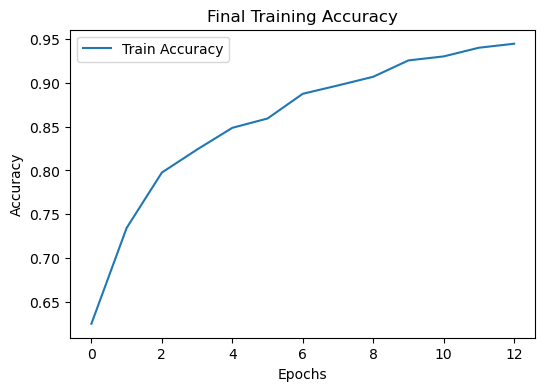

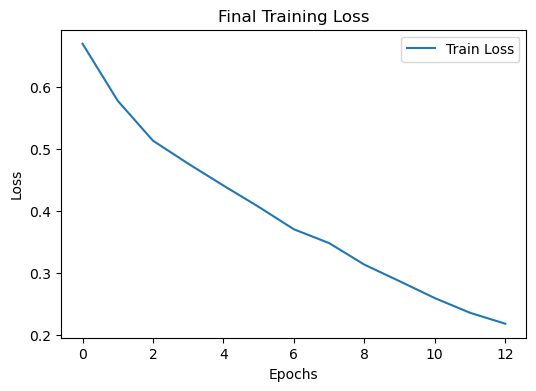

In [27]:
# =====================================
# FINAL TRAINING
# =====================================

final_model = create_bilstm_model(input_shape=(X_train_final.shape[1], X_train_final.shape[2]))

final_epochs = 13

print(f"\nTraining final model...")
history_final = final_model.fit(
    X_train_final, y_train_seq,
    epochs=final_epochs,
    batch_size=64,
    verbose=1
)

# Plot Accuracy
plt.figure(figsize=(6,4))
plt.plot(history_final.history['accuracy'], label='Train Accuracy')
plt.title('Final Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.figure(figsize=(6,4))
plt.plot(history_final.history['loss'], label='Train Loss')
plt.title('Final Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Sequence-Level Evaluation

Evaluating model performance at the individual sequence level (finest granularity):
- **Predictions**: Binary classification for each 20-window sequence
- **Metrics**: Accuracy, precision, recall, F1-score for both classes
- **Confusion Matrix**: True positive/negative vs predicted classifications
- **ROC Curve**: True positive rate vs false positive rate with AUC score
- **Precision-Recall Curve**: Precision vs recall trade-off with average precision
- **Use Case**: Understanding model performance on individual temporal windows

5/5 [==============================] - 1s 4ms/step

Sequence-level Accuracy: 0.9065

Sequence-level Accuracy: 0.9065


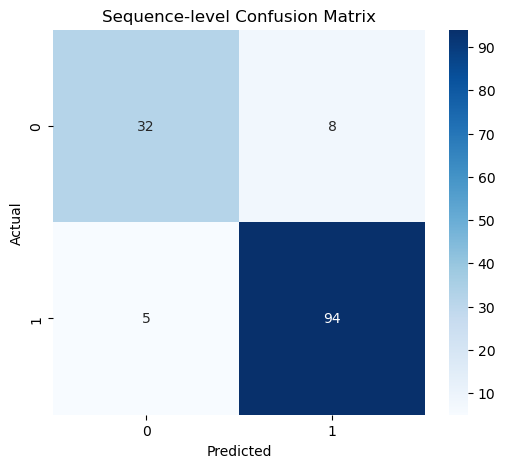


Sequence-level Classification Report:
              precision    recall  f1-score   support

           0     0.8649    0.8000    0.8312        40
           1     0.9216    0.9495    0.9353        99

    accuracy                         0.9065       139
   macro avg     0.8932    0.8747    0.8832       139
weighted avg     0.9053    0.9065    0.9054       139



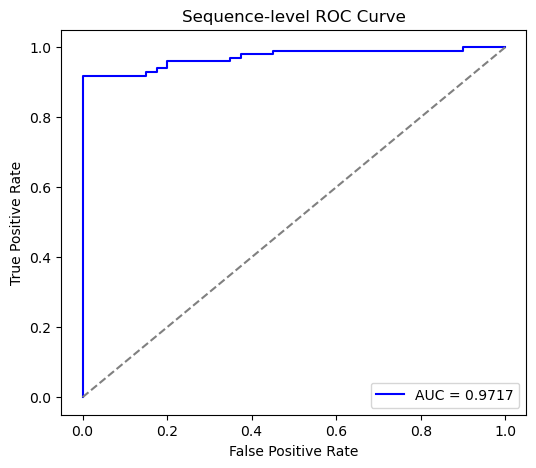

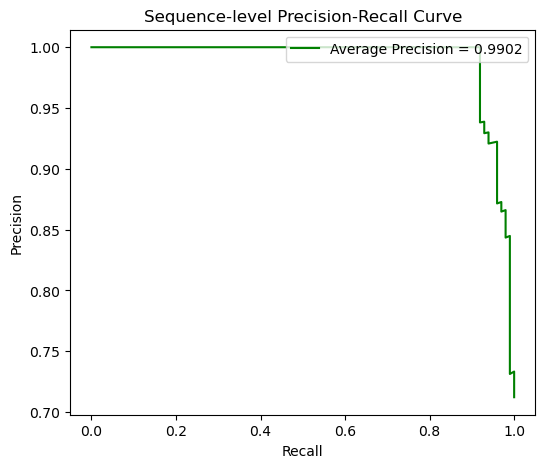

In [28]:
# =====================================
# EVALUATE (SEQUENCE-LEVEL)
# =====================================

# Predict
y_test_pred_prob = final_model.predict(X_test_final)
y_test_pred = (y_test_pred_prob > 0.5).astype(int).flatten()

# Accuracy 
overall_accuracy = accuracy_score(y_test_seq, y_test_pred)
print(f"\nSequence-level Accuracy: {overall_accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test_seq, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sequence-level Confusion Matrix")
plt.show()

# Classification Report
print("\nSequence-level Classification Report:")
print(classification_report(y_test_seq, y_test_pred, digits=4))

# ROC Curve AND AUC
fpr, tpr, thresholds = roc_curve(y_test_seq, y_test_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Sequence-level ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curves
precision, recall, thresholds_pr = precision_recall_curve(y_test_seq, y_test_pred_prob)
avg_precision = average_precision_score(y_test_seq, y_test_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='green', label=f"Average Precision = {avg_precision:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Sequence-level Precision-Recall Curve")
plt.legend(loc="upper right")
plt.show()

# File-Level Evaluation

Aggregating predictions to the file level (one handwriting sample per person):
- **Aggregation Method**: Averaging prediction probabilities across all sequences from the same file
- **Threshold**: 0.5 probability cutoff for binary classification
- **Clinical Relevance**: Each file represents one complete handwriting task
- **Metrics**: Same comprehensive metrics as sequence-level (accuracy, AUC, precision, recall, F1)
- **Use Case**: More stable predictions by combining multiple temporal observations


File-level Accuracy: 0.8103


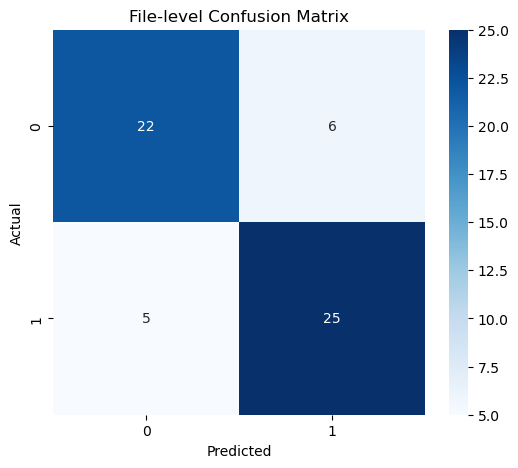


File-level Classification Report:
              precision    recall  f1-score   support

           0     0.8148    0.7857    0.8000        28
           1     0.8065    0.8333    0.8197        30

    accuracy                         0.8103        58
   macro avg     0.8106    0.8095    0.8098        58
weighted avg     0.8105    0.8103    0.8102        58



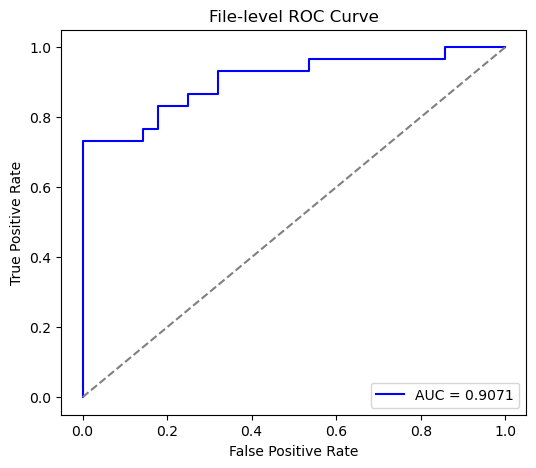

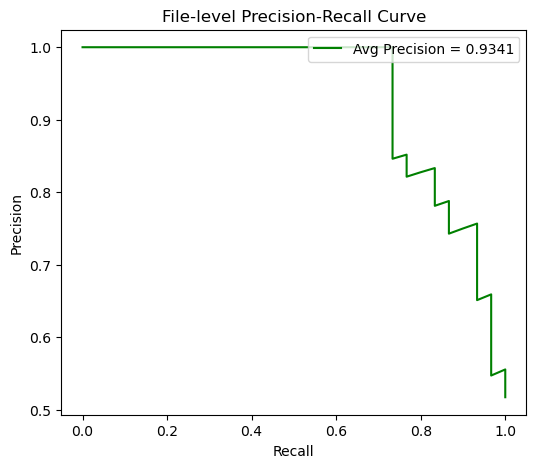

In [29]:
# =====================================
# EVALUATE (FILE-LEVEL)
# =====================================

# Aggregate per file
df_pred = pd.DataFrame({
    "file_name": sequence_file_names_test,
    "true_label": y_test_seq,
    "pred_label": y_test_pred,
    "pred_prob": y_test_pred_prob.flatten()
})

# Average predicted probability for ROC/PR curves
file_level_prob = df_pred.groupby("file_name")["pred_prob"].mean()
file_level_pred = (file_level_prob >= 0.5).astype(int)

# Get true label
file_level_true = df_pred.groupby("file_name")["true_label"].first()

# Accuracy
file_accuracy = accuracy_score(file_level_true, file_level_pred)
print(f"\nFile-level Accuracy: {file_accuracy:.4f}")

# Confusion Matrix
cm_file = confusion_matrix(file_level_true, file_level_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_file, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("File-level Confusion Matrix")
plt.show()

# Classification Report
print("\nFile-level Classification Report:")
print(classification_report(file_level_true, file_level_pred, digits=4))

# ROC Curve & AUC
fpr_file, tpr_file, _ = roc_curve(file_level_true, file_level_prob)
roc_auc_file = auc(fpr_file, tpr_file)

plt.figure(figsize=(6,5))
plt.plot(fpr_file, tpr_file, color='blue', label=f"AUC = {roc_auc_file:.4f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("File-level ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve
precision_file, recall_file, _ = precision_recall_curve(file_level_true, file_level_prob)
avg_precision_file = average_precision_score(file_level_true, file_level_prob)

plt.figure(figsize=(6,5))
plt.plot(recall_file, precision_file, color='green', label=f"Avg Precision = {avg_precision_file:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("File-level Precision-Recall Curve")
plt.legend(loc="upper right")
plt.show()

# Person-Level Evaluation

Aggregating predictions to the person level (highest clinical relevance):
- **Aggregation Method**: Averaging prediction probabilities across all sequences from the same person
- **Threshold**: 0.5 probability cutoff for final diagnosis
- **Clinical Application**: Most relevant for real-world screening scenarios
- **Robustness**: Multiple observations per person reduce noise and outlier effects
- **Metrics**: Same comprehensive evaluation metrics
- **Use Case**: Final diagnostic decision for each individual patient/control


Person-level Accuracy: 0.8889


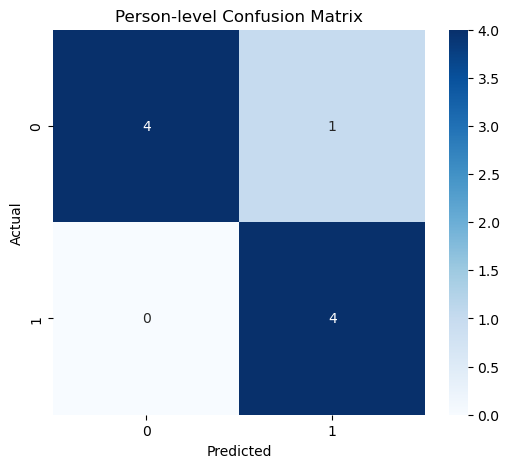


Person-level Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.8000    0.8889         5
           1     0.8000    1.0000    0.8889         4

    accuracy                         0.8889         9
   macro avg     0.9000    0.9000    0.8889         9
weighted avg     0.9111    0.8889    0.8889         9



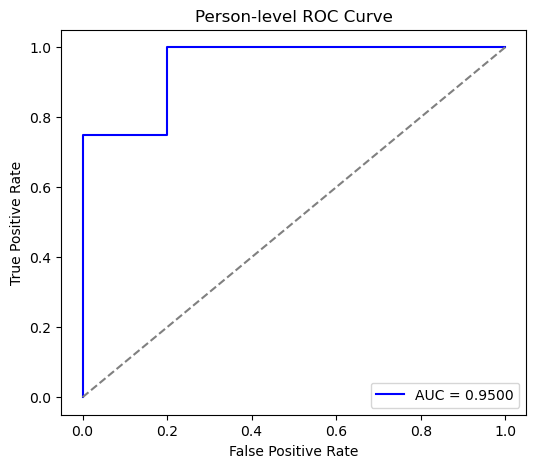

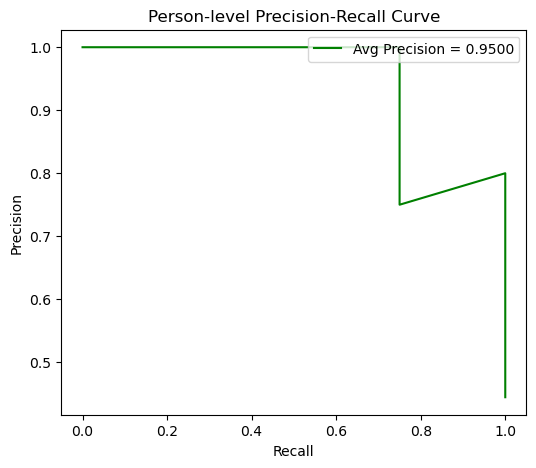

In [30]:
# =====================================
# EVALUATE (PERSON-LEVEL)
# =====================================

# Aggregate per person
df_pred_person = pd.DataFrame({
    "person_id": sequence_person_ids_test,
    "true_label": y_test_seq,   
    "pred_label": y_test_pred,
    "pred_prob": y_test_pred_prob.flatten()
})

# Average predicted probability for ROC/PR curves
person_level_prob = df_pred_person.groupby("person_id")["pred_prob"].mean()
person_level_pred = (person_level_prob >= 0.5).astype(int)

# Get true label
person_level_true = df_pred_person.groupby("person_id")["true_label"].first()

# Accuracy
person_accuracy = accuracy_score(person_level_true, person_level_pred)
print(f"\nPerson-level Accuracy: {person_accuracy:.4f}")

# Confusion Matrix
cm_person = confusion_matrix(person_level_true, person_level_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_person, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Person-level Confusion Matrix")
plt.show()

# Classification Report
print("\nPerson-level Classification Report:")
print(classification_report(person_level_true, person_level_pred, digits=4))

# ROC Curve & AUC
fpr_person, tpr_person, _ = roc_curve(person_level_true, person_level_prob)
roc_auc_person = auc(fpr_person, tpr_person)
plt.figure(figsize=(6,5))
plt.plot(fpr_person, tpr_person, color='blue', label=f"AUC = {roc_auc_person:.4f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Person-level ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve
precision_person, recall_person, _ = precision_recall_curve(person_level_true, person_level_prob)
avg_precision_person = average_precision_score(person_level_true, person_level_prob)
plt.figure(figsize=(6,5))
plt.plot(recall_person, precision_person, color='green', label=f"Avg Precision = {avg_precision_person:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Person-level Precision-Recall Curve")
plt.legend(loc="upper right")
plt.show()

# Multi-Level Performance Comparison

Comprehensive comparison of model performance across all three evaluation granularities:
- **Sequence Level**: Individual predictions on 20-window sequences
- **File Level**: Aggregated predictions per handwriting sample
- **Person Level**: Aggregated predictions per participant
- **Comparison Metrics**: Accuracy, AUC, precision, recall, and F1-score for both classes
- **Expected Pattern**: Performance typically improves with aggregation due to noise reduction
- **Clinical Insight**: Person-level metrics most relevant for diagnostic utility

In [31]:
# =====================================
# COMPARISON TABLE
# =====================================

# Sequence-level metrics
seq_accuracy = overall_accuracy
seq_auc = roc_auc
seq_report = classification_report(y_test_seq, y_test_pred, output_dict=True)

seq_prec_0 = seq_report['0']['precision']
seq_rec_0 = seq_report['0']['recall']
seq_f1_0 = seq_report['0']['f1-score']
seq_prec_1 = seq_report['1']['precision']
seq_rec_1 = seq_report['1']['recall']
seq_f1_1 = seq_report['1']['f1-score']

# File-level metrics
file_acc = file_accuracy
file_auc = roc_auc_file
file_report = classification_report(file_level_true, file_level_pred, output_dict=True)

file_prec_0 = file_report['0']['precision']
file_rec_0 = file_report['0']['recall']
file_f1_0 = file_report['0']['f1-score']
file_prec_1 = file_report['1']['precision']
file_rec_1 = file_report['1']['recall']
file_f1_1 = file_report['1']['f1-score']

# Person-level metrics
person_acc = person_accuracy
person_auc = roc_auc_person
person_report = classification_report(person_level_true, person_level_pred, output_dict=True)

person_prec_0 = person_report['0']['precision']
person_rec_0 = person_report['0']['recall']
person_f1_0 = person_report['0']['f1-score']
person_prec_1 = person_report['1']['precision']
person_rec_1 = person_report['1']['recall']
person_f1_1 = person_report['1']['f1-score']


final_results_table = pd.DataFrame({
    "Metric": [
        "Accuracy", "AUC",
        "Precision (Class 0)", "Recall (Class 0)", "F1 (Class 0)",
        "Precision (Class 1)", "Recall (Class 1)", "F1 (Class 1)"
    ],
    "Sequence Level": [
        f"{seq_accuracy:.4f}", f"{seq_auc:.4f}",
        f"{seq_prec_0:.4f}", f"{seq_rec_0:.4f}", f"{seq_f1_0:.4f}",
        f"{seq_prec_1:.4f}", f"{seq_rec_1:.4f}", f"{seq_f1_1:.4f}"
    ],
    "File Level": [
        f"{file_acc:.4f}", f"{file_auc:.4f}",
        f"{file_prec_0:.4f}", f"{file_rec_0:.4f}", f"{file_f1_0:.4f}",
        f"{file_prec_1:.4f}", f"{file_rec_1:.4f}", f"{file_f1_1:.4f}"
    ],
    "Person Level": [
        f"{person_acc:.4f}", f"{person_auc:.4f}",
        f"{person_prec_0:.4f}", f"{person_rec_0:.4f}", f"{person_f1_0:.4f}",
        f"{person_prec_1:.4f}", f"{person_rec_1:.4f}", f"{person_f1_1:.4f}"
    ]
})

print("\nFinal Performance Comparison: Sequence vs File vs Person Level")
display(final_results_table)


Final Performance Comparison: Sequence vs File vs Person Level


,Metric,Sequence Level,File Level,Person Level
0,Accuracy,0.9065,0.8103,0.8889
1,AUC,0.9717,0.9071,0.9500
2,Precision (Class 0),0.8649,0.8148,1.0000
3,Recall (Class 0),0.8000,0.7857,0.8000
4,F1 (Class 0),0.8312,0.8000,0.8889
5,Precision (Class 1),0.9216,0.8065,0.8000
6,Recall (Class 1),0.9495,0.8333,1.0000
7,F1 (Class 1),0.9353,0.8197,0.8889


# Attention Weights Analysis - Final Model on Test Set

Extracting and analyzing attention weights from the final trained model to understand which temporal patterns drive predictions. This provides:
- **Model Interpretability**: Reveals which time steps the model focuses on for classification
- **Clinical Validation**: Identifies specific moments in writing behavior that distinguish patients from controls
- **Feature Importance**: Shows temporal patterns most indicative of Parkinson's motor impairment
- **Diagnostic Insight**: Helps clinicians understand the basis for automated predictions

In [32]:
# =====================================
# ATTENTION WEIGHTS EXTRACTION
# =====================================
from scipy.stats import shapiro
from scipy import stats

print("\n" + "="*80)
print("ATTENTION WEIGHTS EXTRACTION FROM FINAL MODEL")
print("="*80)

# Create a modified Attention layer that returns both output and weights
class AttentionWithWeights(tf.keras.layers.Layer):
    """Modified Attention layer that returns both output and attention weights"""
    def __init__(self, **kwargs):
        super(AttentionWithWeights, self).__init__(**kwargs)
    
    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(1,), initializer="zeros")
        super(AttentionWithWeights, self).build(input_shape)
    
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1), a

# Find the trained attention layer
trained_attention_layer = None
for layer in final_model.layers:
    if isinstance(layer, Attention):
        trained_attention_layer = layer
        break

if trained_attention_layer is None:
    print("❌ ERROR: No Attention layer found in model!")
else:
    print(f"✅ Found Attention layer: {trained_attention_layer.name}")
    
    # Build attention extraction model
    inputs = Input(shape=(X_test_final.shape[1], X_test_final.shape[2]))
    
    # Get the BiLSTM layer
    bilstm_layer = final_model.layers[1]
    x = bilstm_layer(inputs)
    
    # Get the Dropout layer
    dropout_layer = final_model.layers[2]
    x = dropout_layer(x, training=False)
    
    # Create new attention layer that returns weights
    attention_with_weights = AttentionWithWeights()
    attention_output, attention_weights = attention_with_weights(x)
    
    # Build model that outputs attention weights
    attention_weights_model = Model(inputs=inputs, outputs=attention_weights)
    
    # Copy trained weights from the original attention layer
    attention_with_weights.set_weights(trained_attention_layer.get_weights())
    
    print(f"✅ Attention extraction model built successfully")
    
    # Extract attention weights for test set
    print("\n📊 Extracting attention weights for test set...")
    attention_weights_test = attention_weights_model.predict(X_test_final, batch_size=64, verbose=1)
    attention_weights_test = attention_weights_test.squeeze()
    
    print(f"\nAttention weights shape: {attention_weights_test.shape}")
    
    # Calculate average attention by class
    attention_healthy = attention_weights_test[y_test_seq == 0]
    attention_patient = attention_weights_test[y_test_seq == 1]
    
    print(f"✓ Attention weights extracted successfully!")


ATTENTION WEIGHTS EXTRACTION FROM FINAL MODEL
✅ Found Attention layer: attention_1
✅ Attention extraction model built successfully

📊 Extracting attention weights for test set...
✅ Attention extraction model built successfully

📊 Extracting attention weights for test set...
3/3 [==============================] - 1s 5ms/step

Attention weights shape: (139, 20)
✓ Attention weights extracted successfully!

Attention weights shape: (139, 20)
✓ Attention weights extracted successfully!


In [33]:
# =====================================
# TEMPORAL PROGRESSION ANALYSIS (HYPOTHESIS 4)
# =====================================

print("\n" + "="*80)
print("HYPOTHESIS 4: TEMPORAL PROGRESSION & FATIGUE ANALYSIS")
print("="*80)
print("Research Question: Do attention patterns change differently over time")
print("between Parkinson's patients and healthy controls?")
print("="*80)

# =====================================
# STEP 1: DEFINE TEMPORAL SEGMENTS
# =====================================
print("\n" + "─"*80)
print("STEP 1: TEMPORAL SEGMENT DEFINITIONS")
print("─"*80)

early_segment_size = int(SEQUENCE_LENGTH * 0.25)  # First 25%
late_segment_size = int(SEQUENCE_LENGTH * 0.25)   # Last 25%

early_steps = slice(0, early_segment_size)
late_steps = slice(-late_segment_size, None)

segment_info = pd.DataFrame({
    'Segment': ['Early Phase', 'Late Phase'],
    'Time Steps': [
        f'Steps 1-{early_segment_size}',
        f'Steps {SEQUENCE_LENGTH - late_segment_size + 1}-{SEQUENCE_LENGTH}'
    ],
    'Percentage': ['25%', '25%'],
    'Purpose': [
        'Baseline motor performance',
        'Fatigue/compensation effects'
    ]
})

print("\n" + segment_info.to_string(index=False))

# =====================================
# STEP 2: CALCULATE EARLY VS LATE ATTENTION
# =====================================
print("\n" + "─"*80)
print("STEP 2: EARLY VS LATE ATTENTION COMPARISON")
print("─"*80)

# HEALTHY GROUP
healthy_early = attention_healthy[:, early_steps].mean(axis=1)
healthy_late = attention_healthy[:, late_steps].mean(axis=1)
healthy_temporal_change = healthy_late - healthy_early

# PATIENT GROUP
patient_early = attention_patient[:, early_steps].mean(axis=1)
patient_late = attention_patient[:, late_steps].mean(axis=1)
patient_temporal_change = patient_late - patient_early

early_late_stats = pd.DataFrame({
    'Metric': [
        'Early Attention (mean ± std)',
        'Late Attention (mean ± std)',
        'Temporal Change (Late-Early)',
        'Change Percentage'
    ],
    'Healthy Controls': [
        f"{healthy_early.mean():.6f} ± {healthy_early.std():.6f}",
        f"{healthy_late.mean():.6f} ± {healthy_late.std():.6f}",
        f"{healthy_temporal_change.mean():+.6f} ± {healthy_temporal_change.std():.6f}",
        f"{(healthy_temporal_change.mean() / healthy_early.mean() * 100):+.2f}%"
    ],
    'Parkinson\'s Patients': [
        f"{patient_early.mean():.6f} ± {patient_early.std():.6f}",
        f"{patient_late.mean():.6f} ± {patient_late.std():.6f}",
        f"{patient_temporal_change.mean():+.6f} ± {patient_temporal_change.std():.6f}",
        f"{(patient_temporal_change.mean() / patient_early.mean() * 100):+.2f}%"
    ]
})

print("\n" + early_late_stats.to_string(index=False))

# =====================================
# STEP 3: CALCULATE TEMPORAL SLOPES
# =====================================
print("\n" + "─"*80)
print("STEP 3: TEMPORAL SLOPE ANALYSIS")
print("─"*80)

time_steps = np.arange(SEQUENCE_LENGTH)

healthy_slopes = []
for subject_attention in attention_healthy:
    slope, _ = np.polyfit(time_steps, subject_attention, 1)
    healthy_slopes.append(slope)
healthy_slopes = np.array(healthy_slopes)

patient_slopes = []
for subject_attention in attention_patient:
    slope, _ = np.polyfit(time_steps, subject_attention, 1)
    patient_slopes.append(slope)
patient_slopes = np.array(patient_slopes)

slope_stats = pd.DataFrame({
    'Group': ['Healthy Controls', 'Parkinson\'s Patients'],
    'Mean Slope': [
        f"{healthy_slopes.mean():+.8f}",
        f"{patient_slopes.mean():+.8f}"
    ],
    'Std Deviation': [
        f"{healthy_slopes.std():.8f}",
        f"{patient_slopes.std():.8f}"
    ],
    'Interpretation': [
        'Increasing' if healthy_slopes.mean() > 0 else 'Decreasing',
        'Increasing' if patient_slopes.mean() > 0 else 'Decreasing'
    ]
})

print("\n" + slope_stats.to_string(index=False))


HYPOTHESIS 4: TEMPORAL PROGRESSION & FATIGUE ANALYSIS
Research Question: Do attention patterns change differently over time
between Parkinson's patients and healthy controls?

────────────────────────────────────────────────────────────────────────────────
STEP 1: TEMPORAL SEGMENT DEFINITIONS
────────────────────────────────────────────────────────────────────────────────

    Segment  Time Steps Percentage                      Purpose
Early Phase   Steps 1-5        25%   Baseline motor performance
 Late Phase Steps 16-20        25% Fatigue/compensation effects

────────────────────────────────────────────────────────────────────────────────
STEP 2: EARLY VS LATE ATTENTION COMPARISON
────────────────────────────────────────────────────────────────────────────────

                      Metric     Healthy Controls Parkinson's Patients
Early Attention (mean ± std)  0.047524 ± 0.003899  0.046371 ± 0.002610
 Late Attention (mean ± std)  0.052560 ± 0.004056  0.051215 ± 0.002173
Temporal Ch

In [34]:
# =====================================
# NORMALITY TESTS (HYPOTHESIS 4)
# =====================================

print("\n" + "="*80)
print("NORMALITY TESTS (Shapiro-Wilk Test)")
print("="*80)
print("Testing normality assumption for parametric t-tests")
print("H₀: Data is normally distributed")
print("Significance level: α = 0.05")
print("If p < 0.05, reject H₀ (data is NOT normally distributed)")
print("="*80)

from scipy.stats import shapiro

# =====================================
# TEST 1: WITHIN-GROUP TEMPORAL CHANGES
# =====================================
print("\n" + "─"*80)
print("TEST 1: NORMALITY OF WITHIN-GROUP TEMPORAL CHANGES (Early vs Late)")
print("─"*80)

# Test normality of early and late attention for both groups
stat_healthy_early, p_healthy_early = shapiro(healthy_early)
stat_healthy_late, p_healthy_late = shapiro(healthy_late)
stat_patient_early, p_patient_early = shapiro(patient_early)
stat_patient_late, p_patient_late = shapiro(patient_late)

normality_early_late = pd.DataFrame({
    'Group': [
        'Healthy Early', 'Healthy Late',
        'Patient Early', 'Patient Late'
    ],
    'Sample Size': [
        len(healthy_early), len(healthy_late),
        len(patient_early), len(patient_late)
    ],
    'Shapiro-Wilk Statistic': [
        f"{stat_healthy_early:.6f}", f"{stat_healthy_late:.6f}",
        f"{stat_patient_early:.6f}", f"{stat_patient_late:.6f}"
    ],
    'p-value': [
        f"{p_healthy_early:.10f}", f"{p_healthy_late:.10f}",
        f"{p_patient_early:.10f}", f"{p_patient_late:.10f}"
    ],
    'Normal?': [
        'Yes ✓' if p_healthy_early >= 0.05 else 'No ✗',
        'Yes ✓' if p_healthy_late >= 0.05 else 'No ✗',
        'Yes ✓' if p_patient_early >= 0.05 else 'No ✗',
        'Yes ✓' if p_patient_late >= 0.05 else 'No ✗'
    ]
})

print("\n" + normality_early_late.to_string(index=False))

# =====================================
# TEST 2: TEMPORAL CHANGE NORMALITY
# =====================================
print("\n" + "─"*80)
print("TEST 2: NORMALITY OF TEMPORAL CHANGES (Late - Early)")
print("─"*80)

stat_healthy_change, p_healthy_change = shapiro(healthy_temporal_change)
stat_patient_change, p_patient_change = shapiro(patient_temporal_change)

normality_change = pd.DataFrame({
    'Group': ['Healthy Controls', 'Parkinson\'s Patients'],
    'Sample Size': [len(healthy_temporal_change), len(patient_temporal_change)],
    'Shapiro-Wilk Statistic': [
        f"{stat_healthy_change:.6f}",
        f"{stat_patient_change:.6f}"
    ],
    'p-value': [
        f"{p_healthy_change:.10f}",
        f"{p_patient_change:.10f}"
    ],
    'Normal?': [
        'Yes ✓' if p_healthy_change >= 0.05 else 'No ✗',
        'Yes ✓' if p_patient_change >= 0.05 else 'No ✗'
    ]
})

print("\n" + normality_change.to_string(index=False))

# =====================================
# TEST 3: TEMPORAL SLOPES NORMALITY
# =====================================
print("\n" + "─"*80)
print("TEST 3: NORMALITY OF TEMPORAL SLOPES")
print("─"*80)

stat_healthy_slopes, p_healthy_slopes = shapiro(healthy_slopes)
stat_patient_slopes, p_patient_slopes = shapiro(patient_slopes)

normality_slopes = pd.DataFrame({
    'Group': ['Healthy Controls', 'Parkinson\'s Patients'],
    'Sample Size': [len(healthy_slopes), len(patient_slopes)],
    'Shapiro-Wilk Statistic': [
        f"{stat_healthy_slopes:.6f}",
        f"{stat_patient_slopes:.6f}"
    ],
    'p-value': [
        f"{p_healthy_slopes:.10f}",
        f"{p_patient_slopes:.10f}"
    ],
    'Normal?': [
        'Yes ✓' if p_healthy_slopes >= 0.05 else 'No ✗',
        'Yes ✓' if p_patient_slopes >= 0.05 else 'No ✗'
    ]
})

print("\n" + normality_slopes.to_string(index=False))

# =====================================
# OVERALL NORMALITY ASSESSMENT
# =====================================
print("\n" + "="*80)
print("OVERALL NORMALITY ASSESSMENT")
print("="*80)

# Check if any data violates normality
normality_violations = []
if p_healthy_early < 0.05:
    normality_violations.append("Healthy Early")
if p_healthy_late < 0.05:
    normality_violations.append("Healthy Late")
if p_patient_early < 0.05:
    normality_violations.append("Patient Early")
if p_patient_late < 0.05:
    normality_violations.append("Patient Late")
if p_healthy_change < 0.05:
    normality_violations.append("Healthy Temporal Change")
if p_patient_change < 0.05:
    normality_violations.append("Patient Temporal Change")
if p_healthy_slopes < 0.05:
    normality_violations.append("Healthy Slopes")
if p_patient_slopes < 0.05:
    normality_violations.append("Patient Slopes")

use_nonparametric = len(normality_violations) > 0

if use_nonparametric:
    print("\n⚠️  WARNING: Normality violations detected in:")
    for violation in normality_violations:
        print(f"   • {violation}")
    print("\n✅ RECOMMENDATION: Use NON-PARAMETRIC tests as primary analysis")
    print("   • Within-group: Wilcoxon signed-rank test")
    print("   • Between-group: Mann-Whitney U test")
    print("   Parametric tests will be reported for comparison.")
else:
    print("\n✅ All data normally distributed!")
    print("   Using PARAMETRIC tests (t-tests)")

print("\n" + "="*80)


NORMALITY TESTS (Shapiro-Wilk Test)
Testing normality assumption for parametric t-tests
H₀: Data is normally distributed
Significance level: α = 0.05
If p < 0.05, reject H₀ (data is NOT normally distributed)

────────────────────────────────────────────────────────────────────────────────
TEST 1: NORMALITY OF WITHIN-GROUP TEMPORAL CHANGES (Early vs Late)
────────────────────────────────────────────────────────────────────────────────

        Group  Sample Size Shapiro-Wilk Statistic      p-value Normal?
Healthy Early           40               0.970991 0.3866867292   Yes ✓
 Healthy Late           40               0.986889 0.9167002614   Yes ✓
Patient Early           99               0.800675 0.0000000003    No ✗
 Patient Late           99               0.960040 0.0042944553    No ✗

────────────────────────────────────────────────────────────────────────────────
TEST 2: NORMALITY OF TEMPORAL CHANGES (Late - Early)
──────────────────────────────────────────────────────────────────────

In [35]:
# =====================================
# PARAMETRIC TESTS (T-TESTS)
# =====================================

print("\n" + "="*80)
print("PARAMETRIC STATISTICAL TESTS (T-Tests)")
print("="*80)

from scipy import stats

# Test 1: Within-group paired t-test
print("\n1️⃣  WITHIN-GROUP TEMPORAL CHANGE (Paired t-test)")
print("─" * 70)

t_healthy_within, p_healthy_within = stats.ttest_rel(healthy_early, healthy_late)
t_patient_within, p_patient_within = stats.ttest_rel(patient_early, patient_late)

# Effect sizes
d_healthy_within = (healthy_late.mean() - healthy_early.mean()) / healthy_temporal_change.std()
d_patient_within = (patient_late.mean() - patient_early.mean()) / patient_temporal_change.std()

within_group_parametric = pd.DataFrame({
    'Group': ['Healthy Controls', 'Parkinson\'s Patients'],
    't-statistic': [f"{t_healthy_within:+.4f}", f"{t_patient_within:+.4f}"],
    'p-value': [f"{p_healthy_within:.6f}", f"{p_patient_within:.6f}"],
    'Significance': [
        '***' if p_healthy_within < 0.001 else '**' if p_healthy_within < 0.01 else '*' if p_healthy_within < 0.05 else 'ns',
        '***' if p_patient_within < 0.001 else '**' if p_patient_within < 0.01 else '*' if p_patient_within < 0.05 else 'ns'
    ],
    "Cohen's d": [f"{d_healthy_within:+.4f}", f"{d_patient_within:+.4f}"]
})

print("\n" + within_group_parametric.to_string(index=False))

# Test 2: Between-group independent t-test (Temporal Change)
print("\n\n2️⃣  BETWEEN-GROUP COMPARISON (Independent t-test: Temporal Change)")
print("─" * 70)

t_change, p_change = stats.ttest_ind(healthy_temporal_change, patient_temporal_change)
pooled_std_change = np.sqrt((healthy_temporal_change.std()**2 + patient_temporal_change.std()**2) / 2)
cohens_d_change = (patient_temporal_change.mean() - healthy_temporal_change.mean()) / pooled_std_change

change_parametric = pd.DataFrame({
    'Metric': ['t-statistic', 'p-value', 'Significance', "Cohen's d"],
    'Value': [
        f"{t_change:+.4f}",
        f"{p_change:.6f}",
        '***' if p_change < 0.001 else '**' if p_change < 0.01 else '*' if p_change < 0.05 else 'ns',
        f"{cohens_d_change:+.4f}"
    ]
})

print("\n" + change_parametric.to_string(index=False))

# Test 3: Between-group independent t-test (Slopes)
print("\n\n3️⃣  BETWEEN-GROUP COMPARISON (Independent t-test: Slopes)")
print("─" * 70)

t_slope, p_slope = stats.ttest_ind(healthy_slopes, patient_slopes)
pooled_std_slope = np.sqrt((healthy_slopes.std()**2 + patient_slopes.std()**2) / 2)
cohens_d_slope = (patient_slopes.mean() - healthy_slopes.mean()) / pooled_std_slope

slope_parametric = pd.DataFrame({
    'Metric': ['t-statistic', 'p-value', 'Significance', "Cohen's d"],
    'Value': [
        f"{t_slope:+.4f}",
        f"{p_slope:.6f}",
        '***' if p_slope < 0.001 else '**' if p_slope < 0.01 else '*' if p_slope < 0.05 else 'ns',
        f"{cohens_d_slope:+.4f}"
    ]
})

print("\n" + slope_parametric.to_string(index=False))


PARAMETRIC STATISTICAL TESTS (T-Tests)

1️⃣  WITHIN-GROUP TEMPORAL CHANGE (Paired t-test)
──────────────────────────────────────────────────────────────────────

               Group t-statistic  p-value Significance Cohen's d
    Healthy Controls     -4.5176 0.000057          ***   +0.7234
Parkinson's Patients    -11.0767 0.000000          ***   +1.1189


2️⃣  BETWEEN-GROUP COMPARISON (Independent t-test: Temporal Change)
──────────────────────────────────────────────────────────────────────

      Metric    Value
 t-statistic  +0.1948
     p-value 0.845858
Significance       ns
   Cohen's d  -0.0331


3️⃣  BETWEEN-GROUP COMPARISON (Independent t-test: Slopes)
──────────────────────────────────────────────────────────────────────

      Metric    Value
 t-statistic  -0.1092
     p-value 0.913217
Significance       ns
   Cohen's d  +0.0186


In [36]:
# =====================================
# NON-PARAMETRIC TESTS
# =====================================

print("\n" + "="*80)
print("NON-PARAMETRIC STATISTICAL TESTS")
print("="*80)

from scipy.stats import mannwhitneyu, wilcoxon

# Test 1: Within-group Wilcoxon signed-rank test
print("\n1️⃣  WITHIN-GROUP TEMPORAL CHANGE (Wilcoxon Signed-Rank Test)")
print("─" * 70)

stat_healthy_wilcoxon, p_healthy_wilcoxon = wilcoxon(healthy_early, healthy_late)
stat_patient_wilcoxon, p_patient_wilcoxon = wilcoxon(patient_early, patient_late)

# Effect size using Z derived from W
def compute_wilcoxon_effect_size(W, n):
    mean_w = n * (n + 1) / 4
    std_w  = np.sqrt(n * (n + 1) * (2*n + 1) / 24)
    z = (W - mean_w) / std_w
    r = abs(z) / np.sqrt(n)
    return r

r_healthy_effect = compute_wilcoxon_effect_size(stat_healthy_wilcoxon, len(healthy_early))
r_patient_effect = compute_wilcoxon_effect_size(stat_patient_wilcoxon, len(patient_early))

within_group_nonparametric = pd.DataFrame({
    'Group': ['Healthy Controls', 'Parkinson\'s Patients'],
    'Test Statistic': [f"{stat_healthy_wilcoxon:.2f}", f"{stat_patient_wilcoxon:.2f}"],
    'p-value': [f"{p_healthy_wilcoxon:.6f}", f"{p_patient_wilcoxon:.6f}"],
    'Significance': [
        '***' if p_healthy_wilcoxon < 0.001 else '**' if p_healthy_wilcoxon < 0.01 else '*' if p_healthy_wilcoxon < 0.05 else 'ns',
        '***' if p_patient_wilcoxon < 0.001 else '**' if p_patient_wilcoxon < 0.01 else '*' if p_patient_wilcoxon < 0.05 else 'ns'
    ],
    'Effect Size (r)': [f"{r_healthy_effect:.4f}", f"{r_patient_effect:.4f}"]
})

print("\n" + within_group_nonparametric.to_string(index=False))

# Test 2: Between-group Mann-Whitney U test (Temporal Change)
print("\n\n2️⃣  BETWEEN-GROUP COMPARISON (Mann-Whitney U Test: Temporal Change)")
print("─" * 70)

stat_change_mw, p_change_mw = mannwhitneyu(healthy_temporal_change, patient_temporal_change, alternative='two-sided')

# Effect size (rank-biserial correlation)
n1, n2 = len(healthy_temporal_change), len(patient_temporal_change)
r_rb_change = 1 - (2*stat_change_mw) / (n1 * n2)

change_nonparametric = pd.DataFrame({
    'Metric': ['U Statistic', 'p-value', 'Significance', 'Effect Size (r_rb)'],
    'Value': [
        f"{stat_change_mw:.2f}",
        f"{p_change_mw:.6f}",
        '***' if p_change_mw < 0.001 else '**' if p_change_mw < 0.01 else '*' if p_change_mw < 0.05 else 'ns',
        f"{r_rb_change:+.4f}"
    ]
})

print("\n" + change_nonparametric.to_string(index=False))

# Test 3: Between-group Mann-Whitney U test (Slopes)
print("\n\n3️⃣  BETWEEN-GROUP COMPARISON (Mann-Whitney U Test: Slopes)")
print("─" * 70)

stat_slope_mw, p_slope_mw = mannwhitneyu(healthy_slopes, patient_slopes, alternative='two-sided')
r_rb_slope = 1 - (2*stat_slope_mw) / (n1 * n2)

slope_nonparametric = pd.DataFrame({
    'Metric': ['U Statistic', 'p-value', 'Significance', 'Effect Size (r_rb)'],
    'Value': [
        f"{stat_slope_mw:.2f}",
        f"{p_slope_mw:.6f}",
        '***' if p_slope_mw < 0.001 else '**' if p_slope_mw < 0.01 else '*' if p_slope_mw < 0.05 else 'ns',
        f"{r_rb_slope:+.4f}"
    ]
})

print("\n" + slope_nonparametric.to_string(index=False))


NON-PARAMETRIC STATISTICAL TESTS

1️⃣  WITHIN-GROUP TEMPORAL CHANGE (Wilcoxon Signed-Rank Test)
──────────────────────────────────────────────────────────────────────

               Group Test Statistic  p-value Significance Effect Size (r)
    Healthy Controls         104.00 0.000011          ***          0.6503
Parkinson's Patients         302.00 0.000000          ***          0.7623


2️⃣  BETWEEN-GROUP COMPARISON (Mann-Whitney U Test: Temporal Change)
──────────────────────────────────────────────────────────────────────

            Metric    Value
       U Statistic  1880.00
           p-value 0.643425
      Significance       ns
Effect Size (r_rb)  +0.0505


3️⃣  BETWEEN-GROUP COMPARISON (Mann-Whitney U Test: Slopes)
──────────────────────────────────────────────────────────────────────

            Metric    Value
       U Statistic  1837.00
           p-value 0.507350
      Significance       ns
Effect Size (r_rb)  +0.0722


In [37]:
# =====================================
# HYPOTHESIS 4: FINAL CONCLUSION
# =====================================

print("\n" + "="*80)
print("HYPOTHESIS 4: FINAL CONCLUSION")
print("="*80)

# Determine primary results to use
if use_nonparametric:
    p_within_healthy_final = p_healthy_wilcoxon
    p_within_patient_final = p_patient_wilcoxon
    p_change_final = p_change_mw
    p_slope_final = p_slope_mw
    test_type = "non-parametric (Mann-Whitney U / Wilcoxon)"
else:
    p_within_healthy_final = p_healthy_within
    p_within_patient_final = p_patient_within
    p_change_final = p_change
    p_slope_final = p_slope
    test_type = "parametric (t-tests)"

print(f"\n📊 STATISTICAL APPROACH: Using {test_type}")
print("\n🔍 KEY FINDINGS:")

# Finding 1: Within-group temporal changes
print("\n1. WITHIN-GROUP TEMPORAL CHANGES:")
if p_within_healthy_final < 0.05:
    print(f"   ✓ Healthy controls show SIGNIFICANT temporal change (p={p_within_healthy_final:.6f})")
else:
    print(f"   ✗ Healthy controls show NO significant temporal change (p={p_within_healthy_final:.6f})")

if p_within_patient_final < 0.05:
    print(f"   ✓ Patients show SIGNIFICANT temporal change (p={p_within_patient_final:.6f})")
else:
    print(f"   ✗ Patients show NO significant temporal change (p={p_within_patient_final:.6f})")

# Finding 2: Between-group differences
print("\n2. BETWEEN-GROUP DIFFERENCES:")
if p_change_final < 0.05:
    print(f"   ✓ SIGNIFICANT difference in temporal change between groups (p={p_change_final:.6f})")
    print(f"   • Healthy: {healthy_temporal_change.mean():+.6f}")
    print(f"   • Patient: {patient_temporal_change.mean():+.6f}")
else:
    print(f"   ✗ NO significant difference in temporal change (p={p_change_final:.6f})")

if p_slope_final < 0.05:
    print(f"   ✓ SIGNIFICANT difference in temporal slopes (p={p_slope_final:.6f})")
    print(f"   • Healthy slope: {healthy_slopes.mean():+.8f}")
    print(f"   • Patient slope: {patient_slopes.mean():+.8f}")
else:
    print(f"   ✗ NO significant difference in slopes (p={p_slope_final:.6f})")

# Finding 3: Clinical interpretation
print("\n3. CLINICAL INTERPRETATION:")
if patient_slopes.mean() > healthy_slopes.mean() and p_slope_final < 0.05:
    print("   ✅ COMPENSATORY PATTERN DETECTED:")
    print("      • Patients show significantly INCREASING attention over time")
    print("      • Suggests compensatory effort to maintain motor performance")
    print("      • Clinical relevance: Progressive motor control difficulty")
elif patient_slopes.mean() < healthy_slopes.mean() and p_slope_final < 0.05:
    print("   ⚠️  FATIGUE PATTERN DETECTED:")
    print("      • Patients show significantly DECREASING attention over time")
    print("      • Suggests attentional decline or motor fatigue")
    print("      • Clinical relevance: Reduced sustained attention capacity")
else:
    print("   ❌ NO DIFFERENTIAL TEMPORAL PATTERN:")
    print("      • No significant difference in temporal progression")
    print("      • Both groups maintain similar attention patterns over time")

# Final verdict
print("\n" + "─"*80)
print("📋 HYPOTHESIS 4 VERDICT:")
print("─"*80)

if p_change_final < 0.05 or p_slope_final < 0.05:
    print("✅ HYPOTHESIS SUPPORTED")
    print("   Significant differences exist in temporal attention patterns")
    print("   between Parkinson's patients and healthy controls")
else:
    print("❌ HYPOTHESIS NOT SUPPORTED")
    print("   No significant differences in temporal attention patterns")
    print("   between groups")

print("\n" + "="*80)


HYPOTHESIS 4: FINAL CONCLUSION

📊 STATISTICAL APPROACH: Using non-parametric (Mann-Whitney U / Wilcoxon)

🔍 KEY FINDINGS:

1. WITHIN-GROUP TEMPORAL CHANGES:
   ✓ Healthy controls show SIGNIFICANT temporal change (p=0.000011)
   ✓ Patients show SIGNIFICANT temporal change (p=0.000000)

2. BETWEEN-GROUP DIFFERENCES:
   ✗ NO significant difference in temporal change (p=0.643425)
   ✗ NO significant difference in slopes (p=0.507350)

3. CLINICAL INTERPRETATION:
   ❌ NO DIFFERENTIAL TEMPORAL PATTERN:
      • No significant difference in temporal progression
      • Both groups maintain similar attention patterns over time

────────────────────────────────────────────────────────────────────────────────
📋 HYPOTHESIS 4 VERDICT:
────────────────────────────────────────────────────────────────────────────────
❌ HYPOTHESIS NOT SUPPORTED
   No significant differences in temporal attention patterns
   between groups



In [39]:
# =====================================
# SAVE SCALER AND MODEL
# =====================================

from tensorflow.keras.models import save_model

# Save scaler
with open('final_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save model
final_model.save('final_model.h5')

print("\nScaler and model have been saved.")


Scaler and model have been saved.
